### Imports

In [1]:
import os
import time
import copy
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import sys

print(f"Python: {sys.executable}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")

# Configurando o device (GPU se disponível, senão CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Python: c:\Users\Eduardo\Documents\VisaoComputacional\.venv\Scripts\python.exe
PyTorch: 2.11.0+cu128
CUDA disponível: True
Dispositivo em uso: cuda:0


### Transformações e Carregamento de Dados

In [ ]:
base_dir = '../../chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_base_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['val']) 
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['val'])

# Split (80% Treino / 20% Validação)
targets = full_train_dataset.targets
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.2, stratify=targets, random_state=42
)

train_subset = Subset(full_train_dataset, train_idx)
val_subset = Subset(val_base_dataset, val_idx)

batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_subset), 'val': len(val_subset)}

print(f"Treino: {dataset_sizes['train']} imagens | Validação: {dataset_sizes['val']} imagens")
print(f"Classes: {full_train_dataset.class_to_idx}")

Treino: 4185 imagens | Validação: 1047 imagens
Classes: {'NORMAL': 0, 'PNEUMONIA_BACTERIAL': 1, 'PNEUMONIA_VIRAL': 2}


### Cálculo de Pesos das Classes 

In [8]:
# Contagem de classes no conjunto de treino
train_classes = [targets[i] for i in train_idx]
class_counts = Counter(train_classes)
num_classes = len(full_train_dataset.classes)
total_samples = len(train_classes)

# Fórmula de peso: N_total / (N_classes * N_amostras_da_classe)
class_weights_list = [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)]
class_weights = torch.FloatTensor(class_weights_list).to(device)

print(f"Distribuição no Treino: {class_counts}")
print(f"Pesos Calculados: {class_weights_list}")

Distribuição no Treino: Counter({1: 2030, 0: 1079, 2: 1076})
Pesos Calculados: [1.2928637627432809, 0.687192118226601, 1.296468401486989]


### Construção do Modelo DenseNet121

In [9]:
def create_densenet_model(num_classes=3, freeze_features=True):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False
            
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    return model

model_cnn = create_densenet_model(num_classes=num_classes).to(device)

# Configurando Perda, Otimizador e Scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_cnn.classifier.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("Modelo DenseNet121, Critério e Otimizador inicializados com sucesso.")

Modelo DenseNet121, Critério e Otimizador inicializados com sucesso.


### Loop de Treinamento e Validação

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Época {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            
            progress_bar = tqdm(dataloaders[phase], 
                                desc=f"{phase.capitalize()} Epoch {epoch+1}", 
                                leave=False)

            # Iterando sobre os dados usando a barra de progresso
            for inputs, labels in progress_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + Otimização apenas se estiver no treino
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Atualiza a barra de progresso com a Loss do lote atual em tempo real
                progress_bar.set_postfix({'batch_loss': f"{loss.item():.4f}"})

            # Calcula a média da Loss e Acurácia ao final da época
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                
            # Salva o modelo se a acurácia de validação for a melhor até agora
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print() # Linha em branco para separar as épocas visualmente

    time_elapsed = time.time() - since
    print(f'Treinamento completo em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Melhor Acurácia de Validação: {best_acc:.4f}')

    # Carrega os melhores pesos antes de retornar o modelo
    model.load_state_dict(best_model_wts)
    return model

### Execução do Treinamento

In [ ]:
# Inicia o treinamento
model_cnn = train_model(model_cnn, criterion, optimizer, scheduler, num_epochs=10)

# Salva o modelo treinado para uso futuro
torch.save(model_cnn.state_dict(), 'densenet_pneumonia_best.pth')
print("Pesos do modelo salvos em 'densenet_pneumonia_best.pth'")

Época 1/10
----------


Train Epoch 1:   0%|          | 0/131 [00:06<?, ?it/s]

Train - Loss: 0.8906 Acc: 0.5663


Val Epoch 1:   0%|          | 0/33 [00:05<?, ?it/s]

Val - Loss: 0.7179 Acc: 0.7020

Época 2/10
----------


...

Val - Loss: 0.5650 Acc: 0.7459

Época 10/10
----------


Train Epoch 10:   0%|          | 0/131 [00:06<?, ?it/s]

Train - Loss: 0.6629 Acc: 0.6982


Val Epoch 10:   0%|          | 0/33 [00:05<?, ?it/s]

Val - Loss: 0.5877 Acc: 0.7498

Treinamento completo em 12m 50s
Melhor Acurácia de Validação: 0.7689
Pesos do modelo salvos em 'densenet_pneumonia_best.pth'


### Inferência no Conjunto de Teste e Métricas Principais

In [ ]:
class_names = full_train_dataset.classes

caminho_pesos = 'densenet_pneumonia_best.pth'

if os.path.exists(caminho_pesos):
    # O map_location=device garante que funcione com GPU ou CPU
    model_cnn.load_state_dict(torch.load(caminho_pesos, map_location=device))
    
    # Coloca o modelo em modo de avaliação (desativa dropout, etc.)
    model_cnn.eval() 

def evaluate_model_on_test(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    
    print("Iniciando inferência no conjunto de teste...")
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    print("\nRelatório de Classificação:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    return y_true, y_pred

# Executa a função e guarda os resultados reais e previstos
y_true, y_pred = evaluate_model_on_test(model_cnn, test_loader)

Iniciando inferência no conjunto de teste...

Relatório de Classificação:

                     precision    recall  f1-score   support

             NORMAL       0.86      0.78      0.82       234
PNEUMONIA_BACTERIAL       0.84      0.88      0.86       242
    PNEUMONIA_VIRAL       0.74      0.80      0.77       148

           accuracy                           0.82       624
          macro avg       0.82      0.82      0.82       624
       weighted avg       0.83      0.82      0.82       624



### Matriz de Confusão

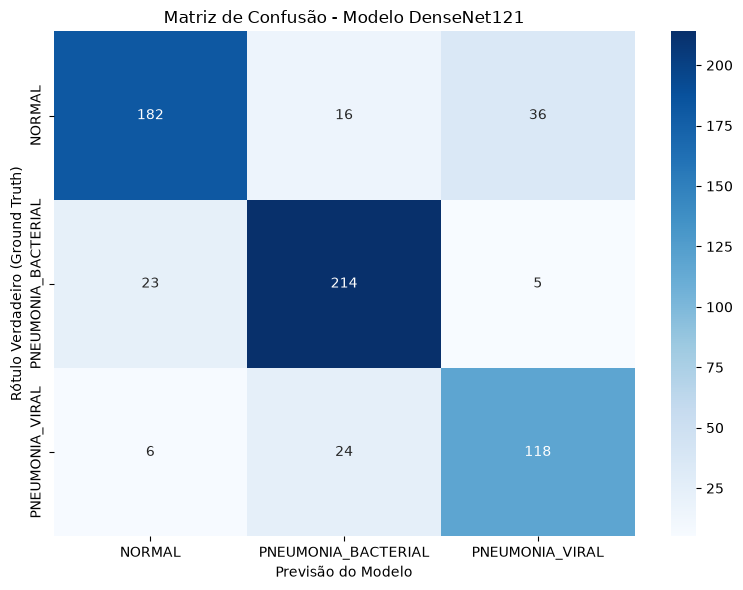

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    # Calcula a matriz
    cm = confusion_matrix(y_true, y_pred)
    
    # Configura o tamanho do gráfico
    plt.figure(figsize=(8, 6))
    
    # Plota o Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, 
                yticklabels=class_names)
    
    plt.title('Matriz de Confusão - Modelo DenseNet121')
    plt.ylabel('Rótulo Verdadeiro (Ground Truth)')
    plt.xlabel('Previsão do Modelo')
    plt.tight_layout()
    plt.show()

# Chama a função para plotar o gráfico
plot_confusion_matrix(y_true, y_pred, class_names)

### Inspeção Visual das Previsões

Amostra de Previsões no Conjunto de Teste:


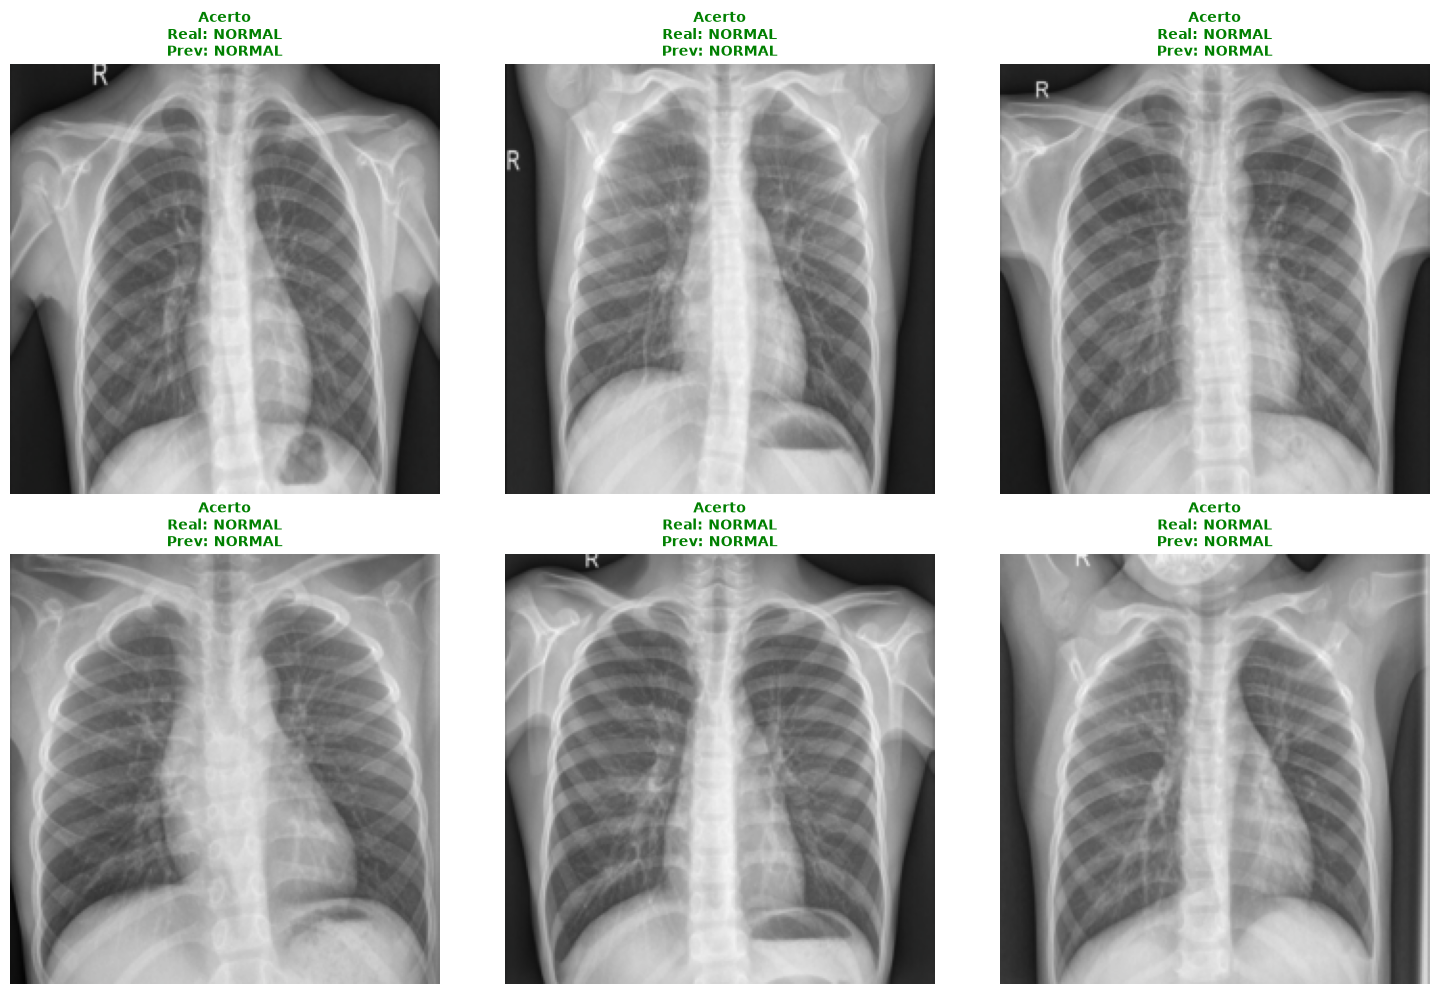

In [ ]:
def imshow_unnormalized(inp, title=None):
    """Reverte a normalização do ImageNet para exibição visual."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=10, fontweight='bold', color='green' if 'Acerto' in title else 'red')
    plt.axis('off')

def visualize_predictions(model, test_loader, class_names, num_images=6):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(2, num_images // 2, images_so_far)
                
                true_label = class_names[labels[j].item()]
                pred_label = class_names[preds[j].item()]
                
                status = "Acerto" if true_label == pred_label else "Erro"
                title = f"{status}\nReal: {true_label}\nPrev: {pred_label}"
                
                imshow_unnormalized(inputs.cpu().data[j], title)
                
                if images_so_far == num_images:
                    plt.tight_layout()
                    plt.show()
                    return

# Plota um grid com 6 imagens do conjunto de teste e suas classificações
print("Amostra de Previsões no Conjunto de Teste:")
visualize_predictions(model_cnn, test_loader, class_names, num_images=6)